In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import scanpy as sc

import os

import scvi 


/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/utils.py:429: 

In [80]:
## Downloaded CR-arc count matrix results
data_dir = '/mnt/hdd_bob/syy/adipose/atac/protocol_benchmark/downloaded_counts/VIB_10xmultiome_2'

h5_file = os.path.join(data_dir, 'GSM7102997_VIB_10xmultiome_2-outs-raw_feature_bc_matrix-matrix.h5ad')

barcodes_file = os.path.join(data_dir, 'GSM7102997_VIB_10xmultiome_2.barcodes.tsv')

features_file = os.path.join(data_dir, 'GSM7102997_VIB_10xmultiome_2.features.tsv')

h5 = sc.read_h5ad(h5_file)

features_pd = pd.read_csv(features_file, header=None, sep='\t')

barcodes_pd = pd.read_csv(barcodes_file, header=None, sep='\t')

## It's feature -by- barcode matrix, need to transpose
h5.var = barcodes_pd
h5.obs = features_pd 
h5.obs.columns = ['feature_id', 'name', 'feature_type', 'chrom', 'start', 'end']
h5.var.columns = ['barcodes']


## Entropy filtered atac
entropy_dir = '/mnt/hdd_bob/syy/adipose/atac/res/VIB_10xmultiome_2_WS3000F'
entropy_downstream_dir = os.path.join(entropy_dir, 'DownstreamReanalysis')
entropy_peak_file = os.path.join(entropy_downstream_dir, 'entropy_peakvi.h5ad')
peak_file = os.path.join(entropy_downstream_dir, 'peakvi.h5ad')

entropy_peak = sc.read_h5ad(entropy_peak_file)
peak = sc.read_h5ad(peak_file)

# atac-rna-barcode map 
bc_map_file = '/home/syyang/adipose_ln/multiom/atac_rna_barcodes_map.tsv'
bc_map_pd = pd.read_csv(bc_map_file, sep='\t')


In [81]:
entropy_peak, peak, h5, features_pd.shape, barcodes_pd.shape, bc_map_pd.shape

(AnnData object with n_obs × n_vars = 2125 × 36729
     obs: 'barcodes', '_scvi_batch', '_scvi_labels', 'clusters_peakvi'
     var: 'peak'
     uns: '_scvi_manager_uuid', '_scvi_uuid', 'clusters_peakvi', 'neighbors', 'umap'
     obsm: 'X_peakvi', 'X_umap'
     obsp: 'connectivities', 'distances',
 AnnData object with n_obs × n_vars = 2125 × 31116
     obs: 'barcodes', '_scvi_batch', '_scvi_labels', 'clusters_peakvi'
     var: 'peak'
     uns: '_scvi_manager_uuid', '_scvi_uuid', 'clusters_peakvi', 'neighbors', 'umap'
     obsm: 'X_peakvi', 'X_umap'
     obsp: 'connectivities', 'distances',
 AnnData object with n_obs × n_vars = 104068 × 687495
     obs: 'feature_id', 'name', 'feature_type', 'chrom', 'start', 'end'
     var: 'barcodes',
 (104068, 6),
 (687495, 1),
 (736320, 2))

## plot atac clustering results

In [82]:
# atac clsutering at different resolutions
atac_resolution = 0.5
sc.tl.leiden(entropy_peak, key_added='clusters_peakvi_entropy', resolution=atac_resolution)
sc.tl.leiden(peak, key_added='clusters_peakvi_all', resolution=atac_resolution)

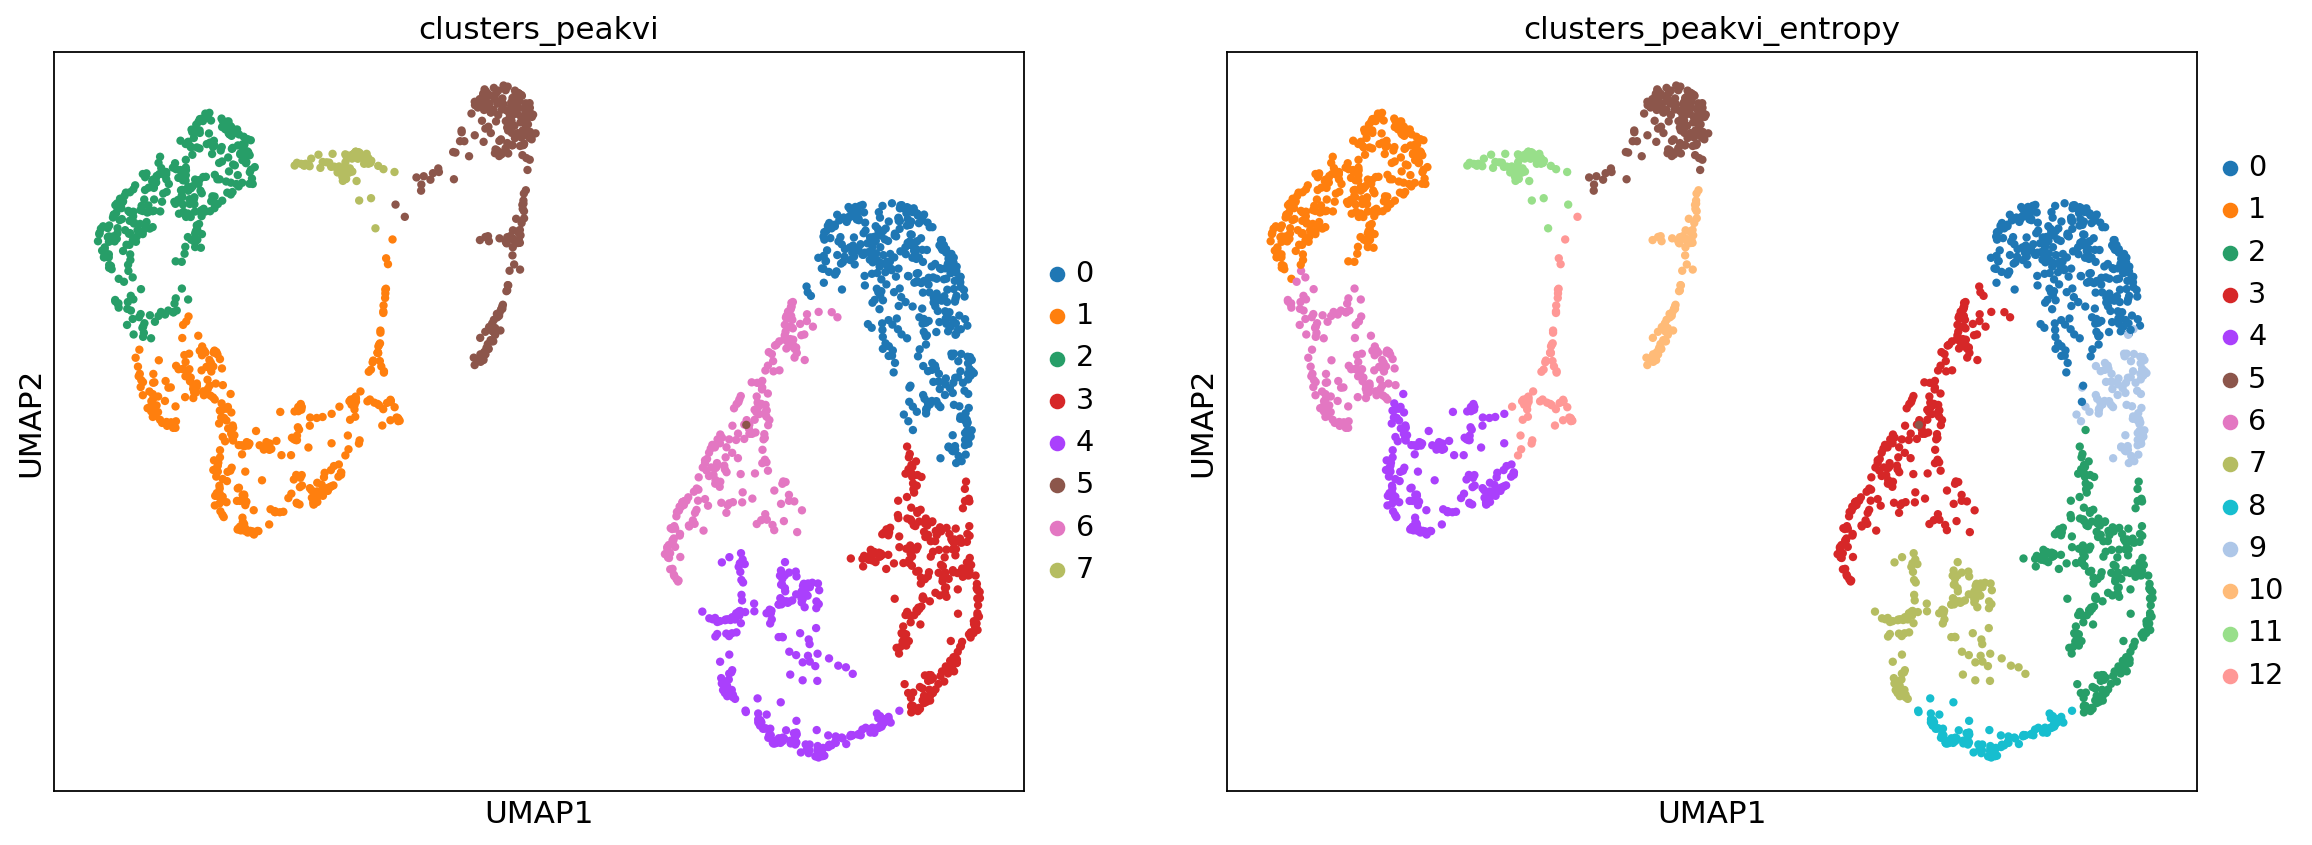

In [84]:
with plt.rc_context({'figure.figsize': (8, 6)}):
    sc.pl.umap(entropy_peak, color=['clusters_peakvi', 'clusters_peakvi_entropy'], wspace=0.1)

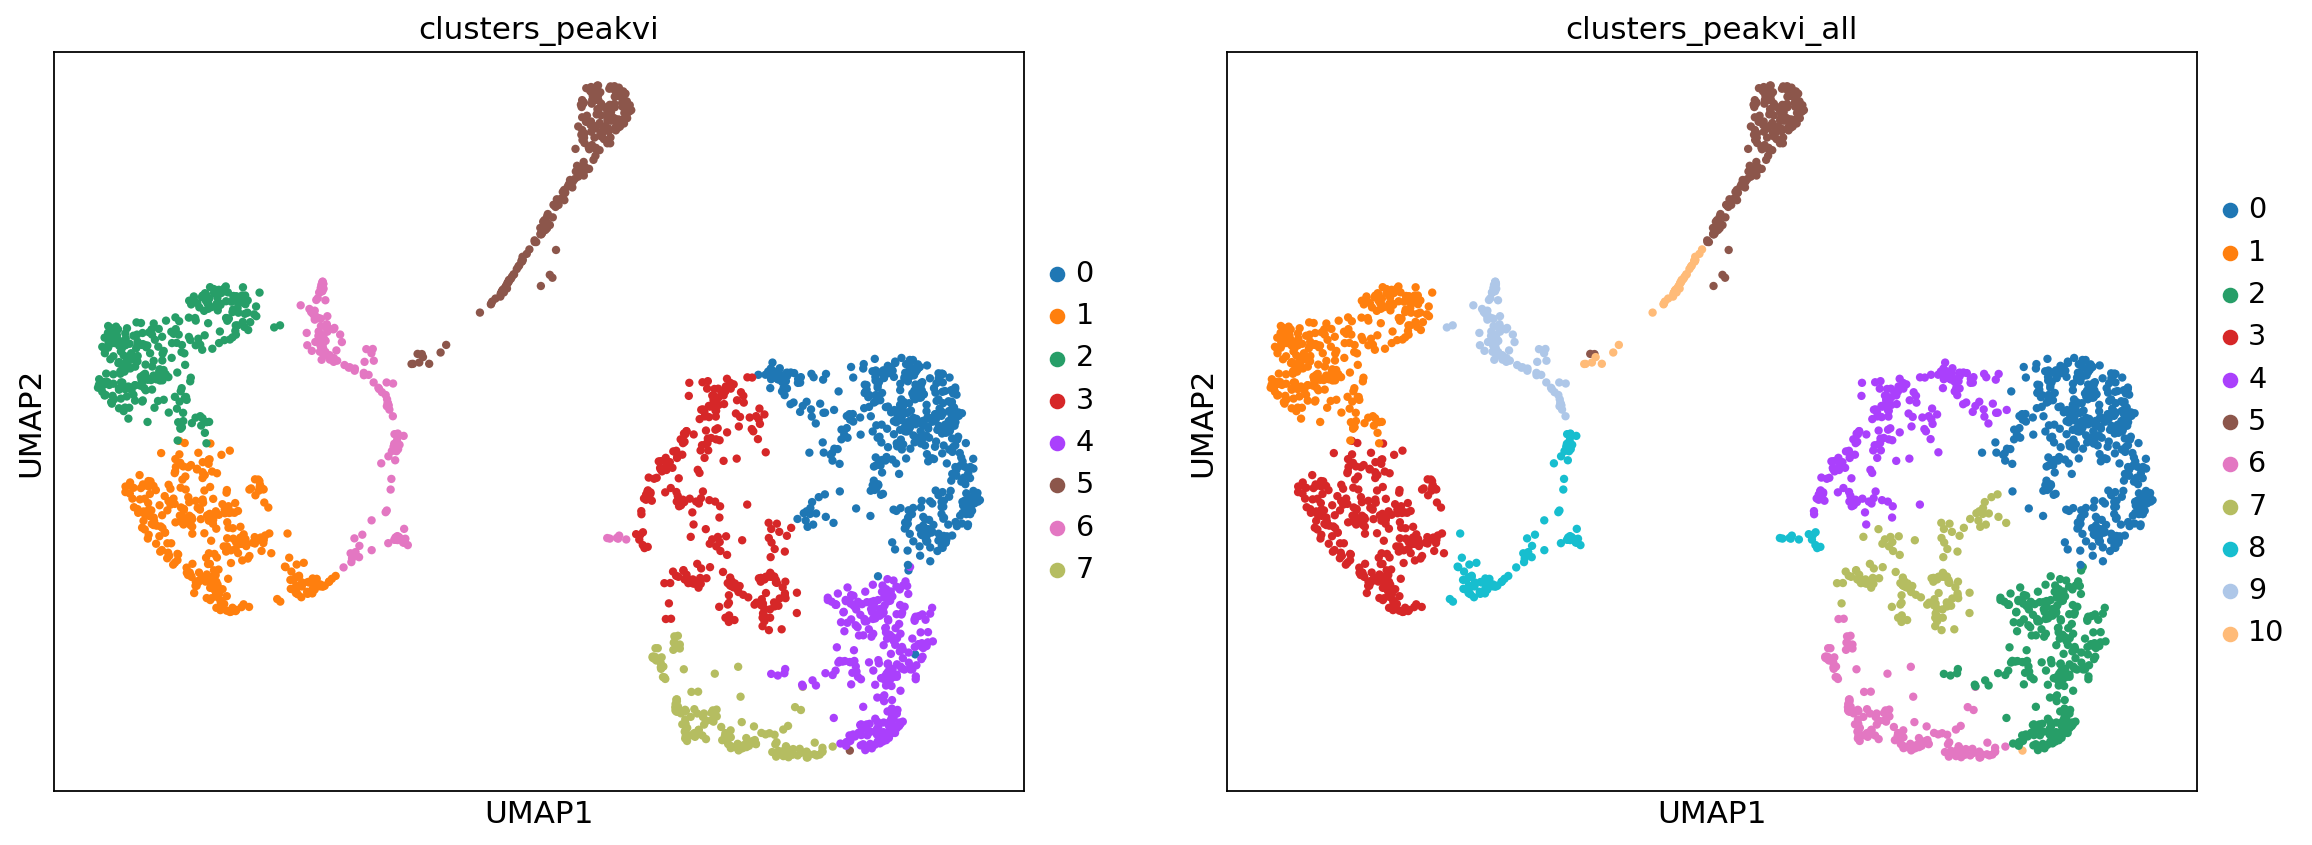

In [85]:
with plt.rc_context({'figure.figsize': (8, 6)}):
    sc.pl.umap(peak, color=['clusters_peakvi', 'clusters_peakvi_all'], wspace=0.1)

In [86]:
entropy_peak.obs['clusters_peakvi_r_entropy'] = entropy_peak.obs['clusters_peakvi']  # Add suffix for name
peak.obs['clusters_peakvi_r_all'] = peak.obs['clusters_peakvi']

In [87]:
entropy_peak_df = entropy_peak.obs.copy()
entropy_peak_df.set_index('barcodes', inplace=True)

peak_df = peak.obs.copy()
peak_df.set_index('barcodes', inplace=True)

peak_df.join(entropy_peak_df['clusters_peakvi_entropy']).groupby(['clusters_peakvi_all', 'clusters_peakvi_entropy']).size().unstack(fill_value=0)


/tmp/ipykernel_3915683/1058780932.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  peak_df.join(entropy_peak_df['clusters_peakvi_entropy']).groupby(['clusters_peakvi_all', 'clusters_peakvi_entropy']).size().unstack(fill_value=0)


clusters_peakvi_entropy,0,1,2,3,4,5,6,7,8,9,10,11,12
clusters_peakvi_all,,,,,,,,,,,,,
0,306,0,3,13,0,0,0,0,0,76,0,1,0
1,0,278,0,0,0,0,18,0,0,0,1,2,0
2,0,0,243,0,0,1,0,4,2,13,0,1,0
3,0,8,0,0,126,0,124,0,0,0,2,0,0
4,10,0,0,178,0,0,0,1,0,0,0,0,0
5,0,0,0,1,0,141,0,0,0,0,40,1,0
6,0,0,12,0,0,0,0,31,108,0,0,0,0
7,1,0,2,20,0,0,0,99,0,4,0,0,0
8,0,0,0,7,47,0,0,0,0,0,0,1,55


## Matching atac bc with RNA bc

In [88]:
bc_map = bc_map_pd.set_index('atac_barcodes')

entropy_peak.obs['atac_bc'] =  entropy_peak.obs['barcodes'].map(lambda x: x.split('-1')[0])
entropy_peak.obs.set_index('atac_bc', inplace=True)
if 'rna_barcodes' not in entropy_peak.obs.columns:
    entropy_peak.obs = entropy_peak.obs.join(bc_map, how='inner')


peak.obs['atac_bc'] =  peak.obs['barcodes'].map(lambda x: x.split('-1')[0])
peak.obs.set_index('atac_bc', inplace=True)
if 'rna_barcodes' not in peak.obs.columns:
    peak.obs = peak.obs.join(bc_map, how='inner')


bc_passed_entropy_df = entropy_peak.obs[['rna_barcodes']]

## RNA clustering

In [92]:
# prepare for rna-bc correspondence to atac entropy filtered barcodes
entropy_passed_bc_map=bc_passed_entropy_df.reset_index(inplace=False)
entropy_passed_bc_map.set_index('rna_barcodes', inplace=True)
entropy_passed_bc_map.columns = ['atac_bc']


h5_rna = h5.transpose()
h5_rna.obs['rna_barcodes'] = h5_rna.obs['barcodes'].map(lambda x: x.split('-1')[0])
h5_rna.obs.set_index('rna_barcodes', inplace=True)


# select gene expression only, and only the barcodes that passed entropy filtering
h5_rna = h5_rna[:, h5_rna.var['feature_type'] == 'Gene Expression']
h5_rna = h5_rna[h5_rna.obs.index.isin(entropy_passed_bc_map.index), :]
h5_rna.obs = h5_rna.obs.join(entropy_passed_bc_map, how='inner')

# calculate total RNA UMI log-scale
h5_rna.obs['total_RNA_UMI_log'] = np.log1p(h5_rna.X.sum(axis=1))


/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [93]:
h5_rna

AnnData object with n_obs × n_vars = 2125 × 36601
    obs: 'barcodes', 'atac_bc', 'total_RNA_UMI_log'
    var: 'feature_id', 'name', 'feature_type', 'chrom', 'start', 'end'

In [112]:
sc.pp.filter_genes(h5_rna, min_counts=3)
h5_rna.raw = h5_rna # keep full dimension safe
h5_rna.layers['counts'] = h5_rna.X
sc.pp.highly_variable_genes(
h5_rna,
flavor="seurat_v3",
n_top_genes=4000,
layer="counts",
subset=False)

In [113]:
scvi.settings.seed = 0
scvi.model.SCVI.setup_anndata(h5_rna, layer="counts")
vae = scvi.model.SCVI(h5_rna, n_layers=3, n_latent=30, gene_likelihood="nb")
vae.train()
h5_rna.obsm["RNA_scVI"] = vae.get_latent_representation()


sc.pp.neighbors(h5_rna, use_rep='RNA_scVI')
sc.tl.umap(h5_rna, min_dist=0.3)

# clustering using scVI latent representation via Leiden
sc.tl.leiden(h5_rna, key_added="leiden_RNA_scVI", resolution=atac_resolution)

# print("Save integrated samples into .h5ad file and trained SCVI model into subfolder\n") 
# vae_model_folder=os.path.join(args.o[0], "integrated_scvi_model")
# vae.save(vae_model_folder)

Seed set to 0
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/scvi/model/_scvi.py:168: UserWarning: This dataset has some empty cells, this might fail inference.Data should be filtered with `scanpy.pp.filter_cells()`
  library_log_means, library_log_vars = _init_library_size(
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:424: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the 

Epoch 400/400: 100%|██████████| 400/400 [01:27<00:00,  4.58it/s, v_num=1, train_loss_step=5.33e+3, train_loss_epoch=5.27e+3]

`Trainer.fit` stopped: `max_epochs=400` reached.


Epoch 400/400: 100%|██████████| 400/400 [01:27<00:00,  4.56it/s, v_num=1, train_loss_step=5.33e+3, train_loss_epoch=5.27e+3]


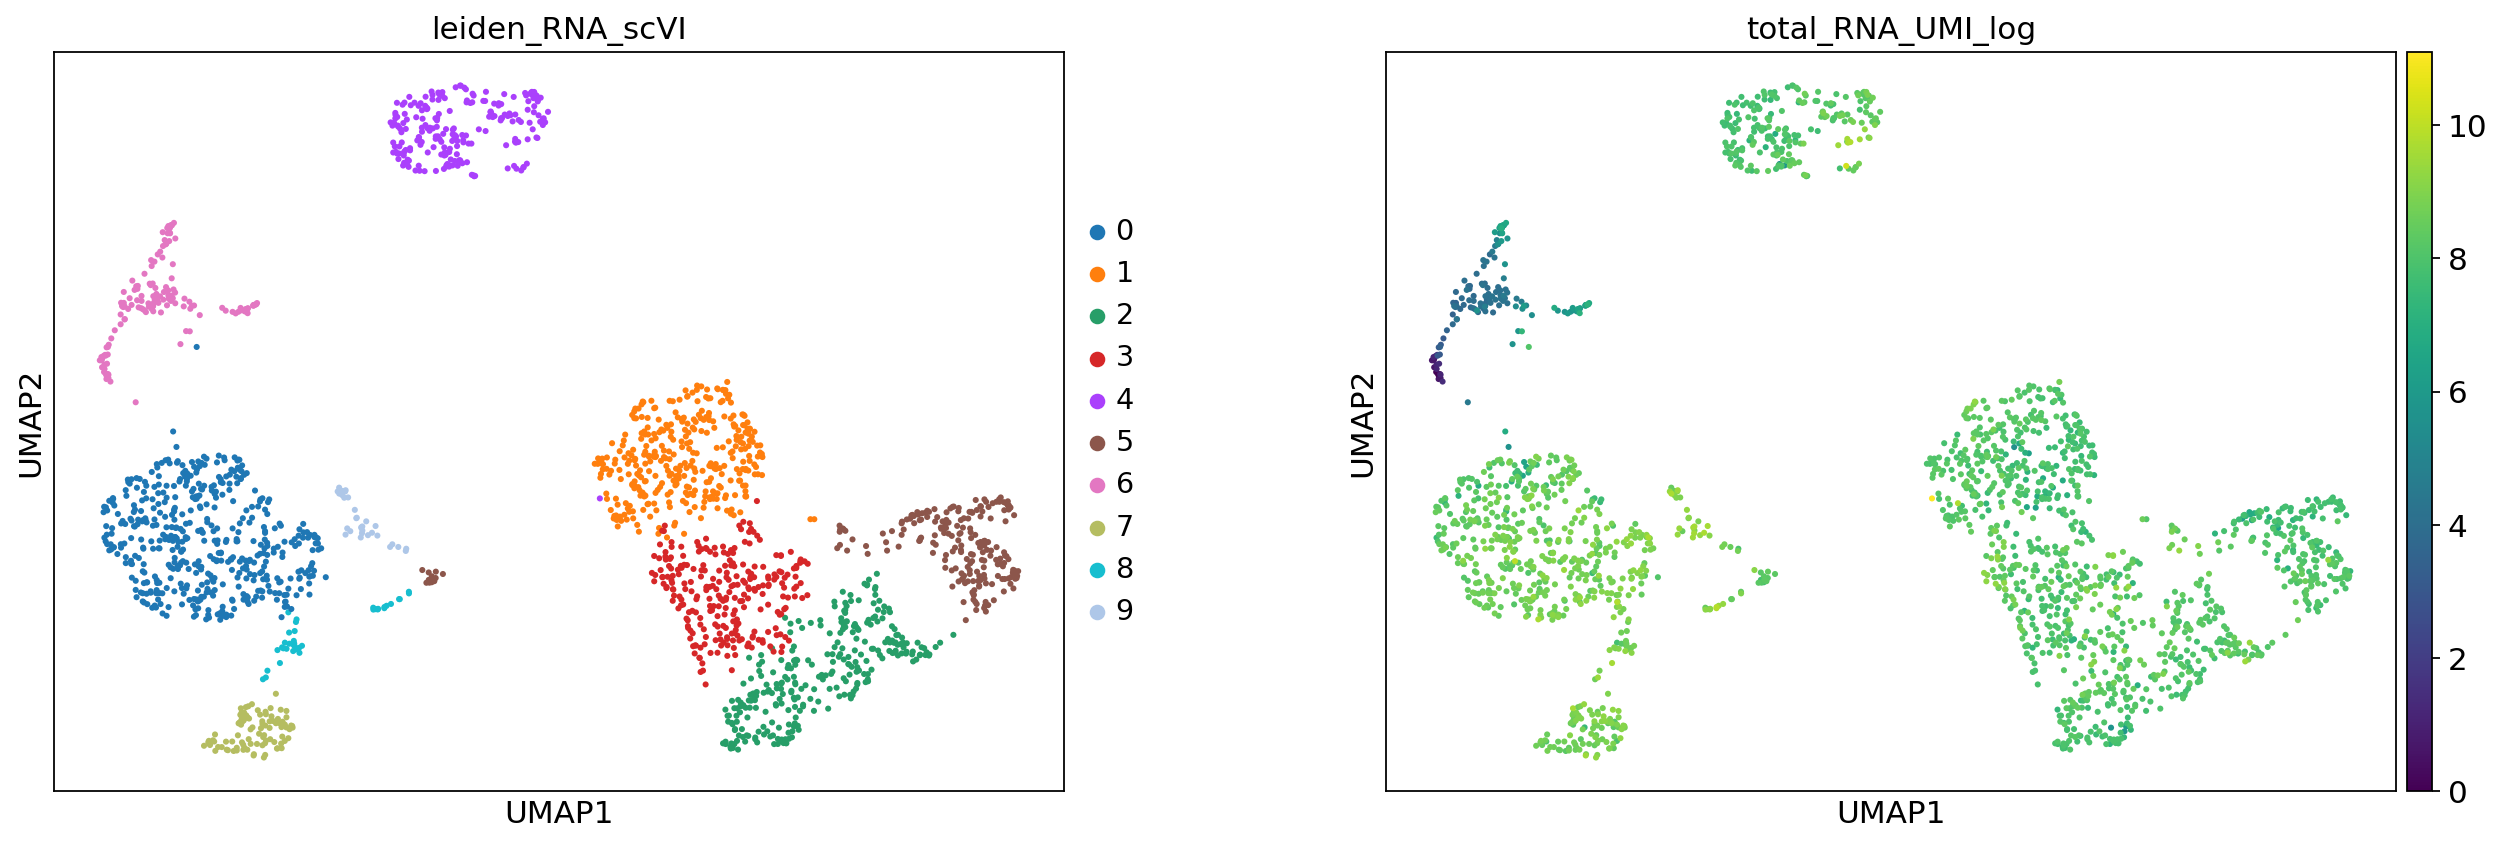

In [114]:
with plt.rc_context({'figure.figsize': (8, 6)}):
    sc.pl.umap(h5_rna, color=['leiden_RNA_scVI', 'total_RNA_UMI_log'], wspace=0.2, size=30)

## Plot to see consistency between atac space and rna space 

In [116]:
if 'clusters_peakvi_entropy' in h5_rna.obs.columns:
    h5_rna.obs.drop('clusters_peakvi_entropy', axis=1, inplace=True)
if 'clusters_peakvi_r_entropy' in h5_rna.obs.columns:
    h5_rna.obs.drop('clusters_peakvi_r_entropy', axis=1, inplace=True)

if 'clusters_peakvi_all' in h5_rna.obs.columns:
    h5_rna.obs.drop('clusters_peakvi_all', axis=1, inplace=True)
if 'clusters_peakvi_r_all' in h5_rna.obs.columns:
    h5_rna.obs.drop('clusters_peakvi_r_all', axis=1, inplace=True)
    

h5_rna.obs = h5_rna.obs.merge(entropy_peak.obs[['clusters_peakvi_entropy', 'clusters_peakvi_r_entropy']], left_on='atac_bc', right_index=True, how='left')
# h5_rna.obs.rename(columns={'clusters_peakvi':'clusters_peakvi_entropy'}, inplace=True)
h5_rna.obs = h5_rna.obs.merge(peak.obs[['clusters_peakvi_all', 'clusters_peakvi_r_all']], left_on='atac_bc', right_index=True, how='left')

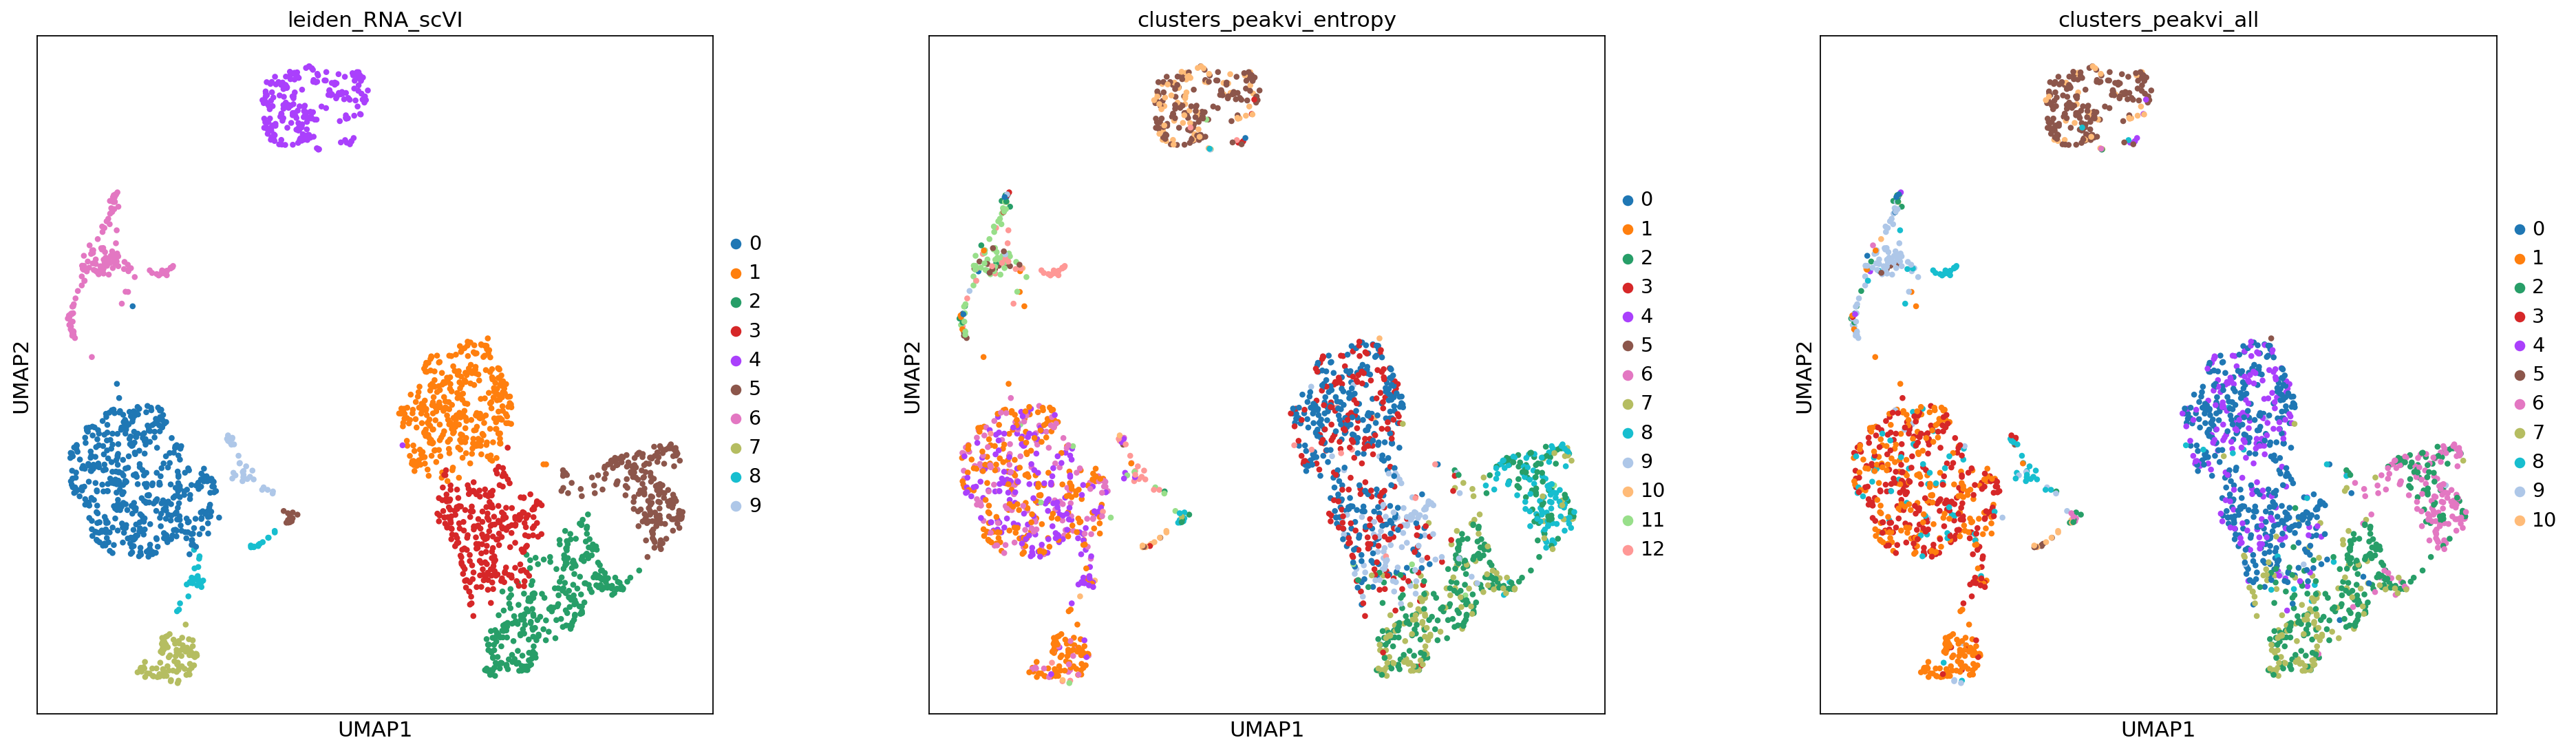

In [117]:
with plt.rc_context({'figure.figsize': (8, 8)}):
    sc.pl.umap(h5_rna, color=['leiden_RNA_scVI', 'clusters_peakvi_entropy', 'clusters_peakvi_all'], wspace=0.2, ncols=3, size=60)

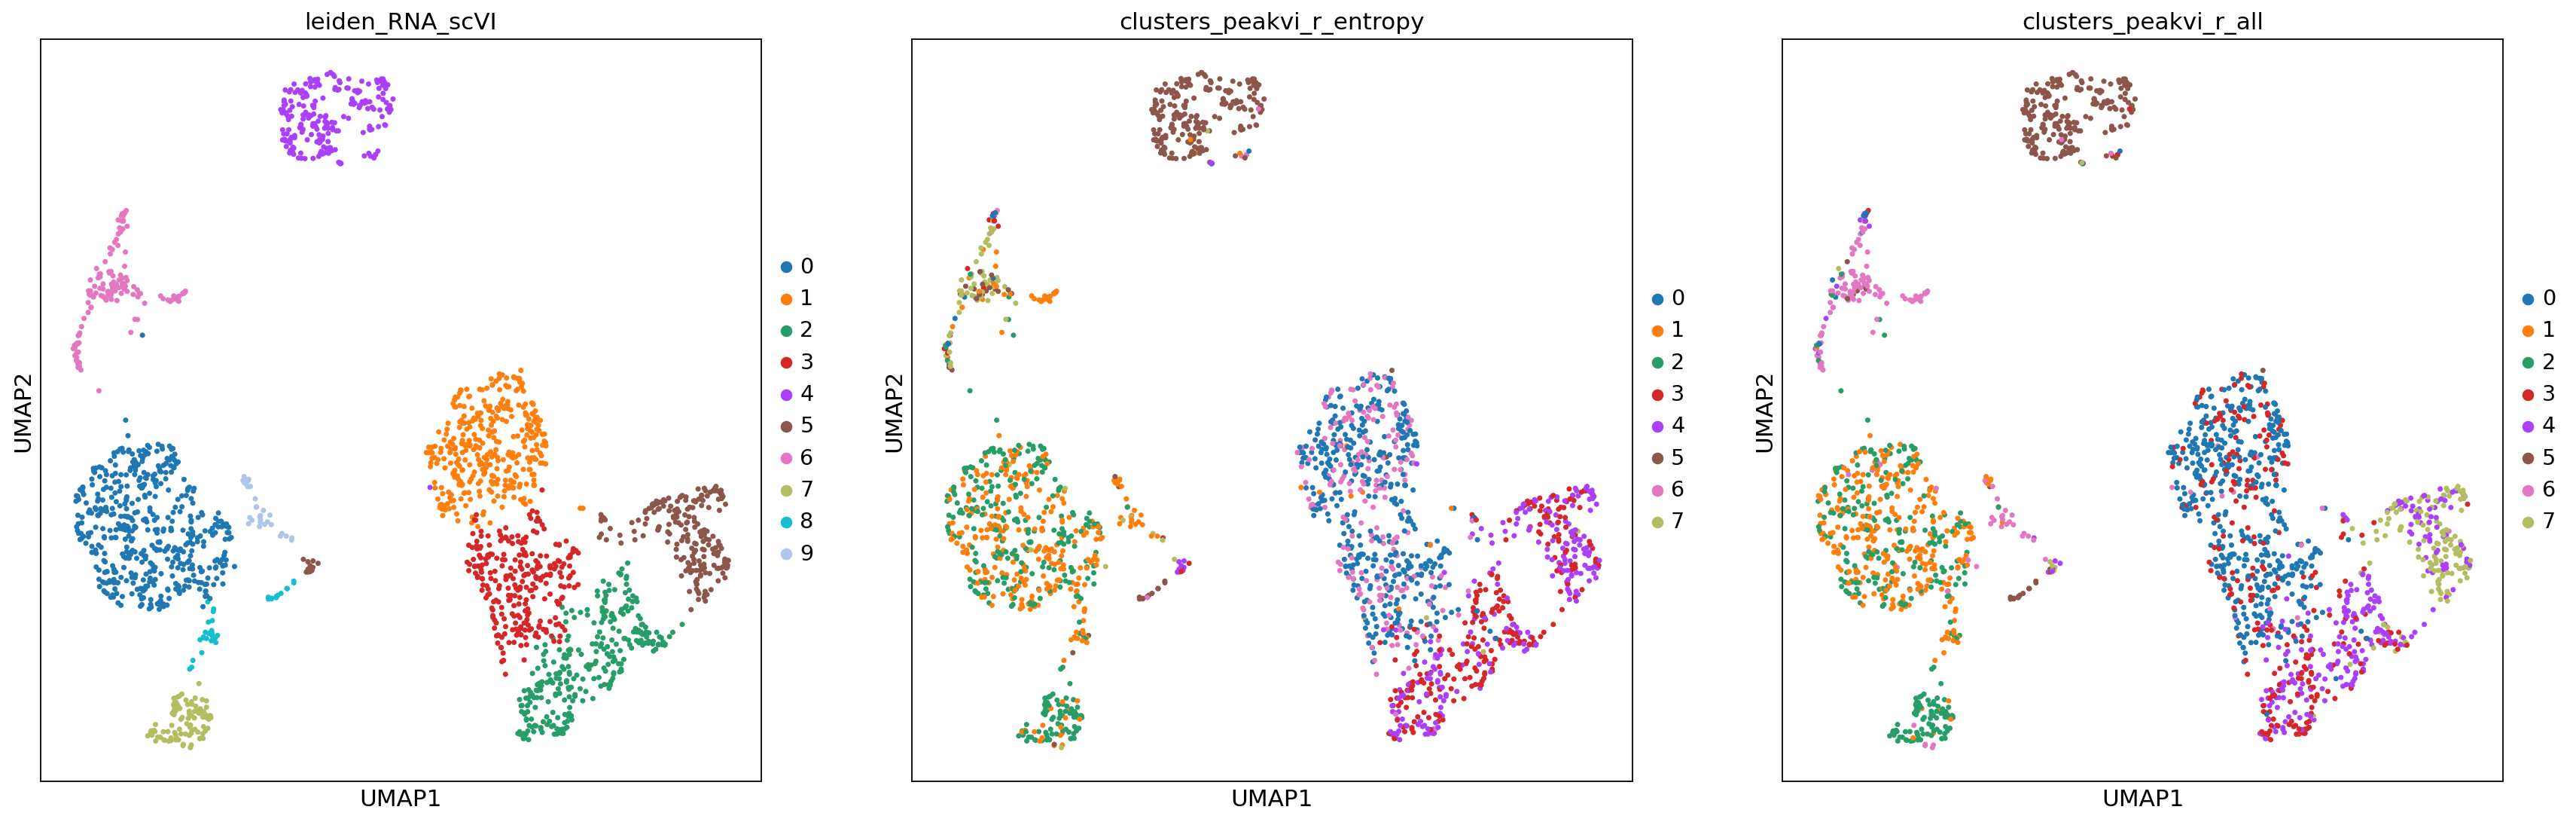

In [118]:
with plt.rc_context({'figure.figsize': (8, 8)}):
    sc.pl.umap(h5_rna, color=['leiden_RNA_scVI', 'clusters_peakvi_r_entropy', 'clusters_peakvi_r_all'], wspace=0.1, ncols=3, size=40)

### match cluster by majority 

In [119]:
relate_labels = peak_df.join(entropy_peak_df['clusters_peakvi_r_entropy']).groupby(['clusters_peakvi_r_all', 'clusters_peakvi_r_entropy']).size().unstack(fill_value=0)

relate_labels = relate_labels.to_numpy()

ordered_col, remained_col = order_m(relate_labels)

relate_labels[:, ordered_col + remained_col]

/tmp/ipykernel_3915683/3076325161.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  relate_labels = peak_df.join(entropy_peak_df['clusters_peakvi_r_entropy']).groupby(['clusters_peakvi_r_all', 'clusters_peakvi_r_entropy']).size().unstack(fill_value=0)


array([[403,   0,   0,  56,   3,   0,   1,   0],
       [  0, 263,  39,   0,   0,   2,   0,   0],
       [  0,  11, 287,   0,   0,   1,   2,   0],
       [  0,   0,   0, 159,   2,   0,   0, 102],
       [ 11,   0,   0,   0, 242,   1,   1,   6],
       [  0,   1,   0,   1,   0, 221,   3,   2],
       [  2,  72,   3,   0,   2,  15,  62,   0],
       [  0,   0,   0,   0,  12,   0,   0, 137]])

In [ ]:
# # Now manually map the best matching clusters
cluster_map = {str(i):str(j) for i, j in zip(list(range(relate_labels.shape[1])), ordered_col+remained_col)}
cluster_map
#entropy_peak.obs['clusters_peakvi_reorder_entropy'] = entropy_peak.obs['clusters_peakvi_r_entropy'].map(cluster_map)

entropy_peak.obs['clusters_peakvi_reorder_entropy'] = entropy_peak.obs['clusters_peakvi_r_entropy'].cat.reorder_categories([str(i) for i in ordered_col+remained_col], ordered=False)
# sc.pl.umap(entropy_peak, color='clusters_peakvi_reorder_entropy')

In [121]:
if 'clusters_peakvi_entropy' in h5_rna.obs.columns:
    h5_rna.obs.drop('clusters_peakvi_entropy', axis=1, inplace=True)
if 'clusters_peakvi_reorder_entropy' in h5_rna.obs.columns:
    h5_rna.obs.drop('clusters_peakvi_reorder_entropy', axis=1, inplace=True)

if 'clusters_peakvi_all' in h5_rna.obs.columns:
    h5_rna.obs.drop('clusters_peakvi_all', axis=1, inplace=True)
if 'clusters_peakvi_r_all' in h5_rna.obs.columns:
    h5_rna.obs.drop('clusters_peakvi_r_all', axis=1, inplace=True)
    

h5_rna.obs = h5_rna.obs.merge(entropy_peak.obs[['clusters_peakvi_entropy', 'clusters_peakvi_reorder_entropy']], left_on='atac_bc', right_index=True, how='left')
# h5_rna.obs.rename(columns={'clusters_peakvi':'clusters_peakvi_entropy'}, inplace=True)
h5_rna.obs = h5_rna.obs.merge(peak.obs[['clusters_peakvi_all', 'clusters_peakvi_r_all']], left_on='atac_bc', right_index=True, how='left')

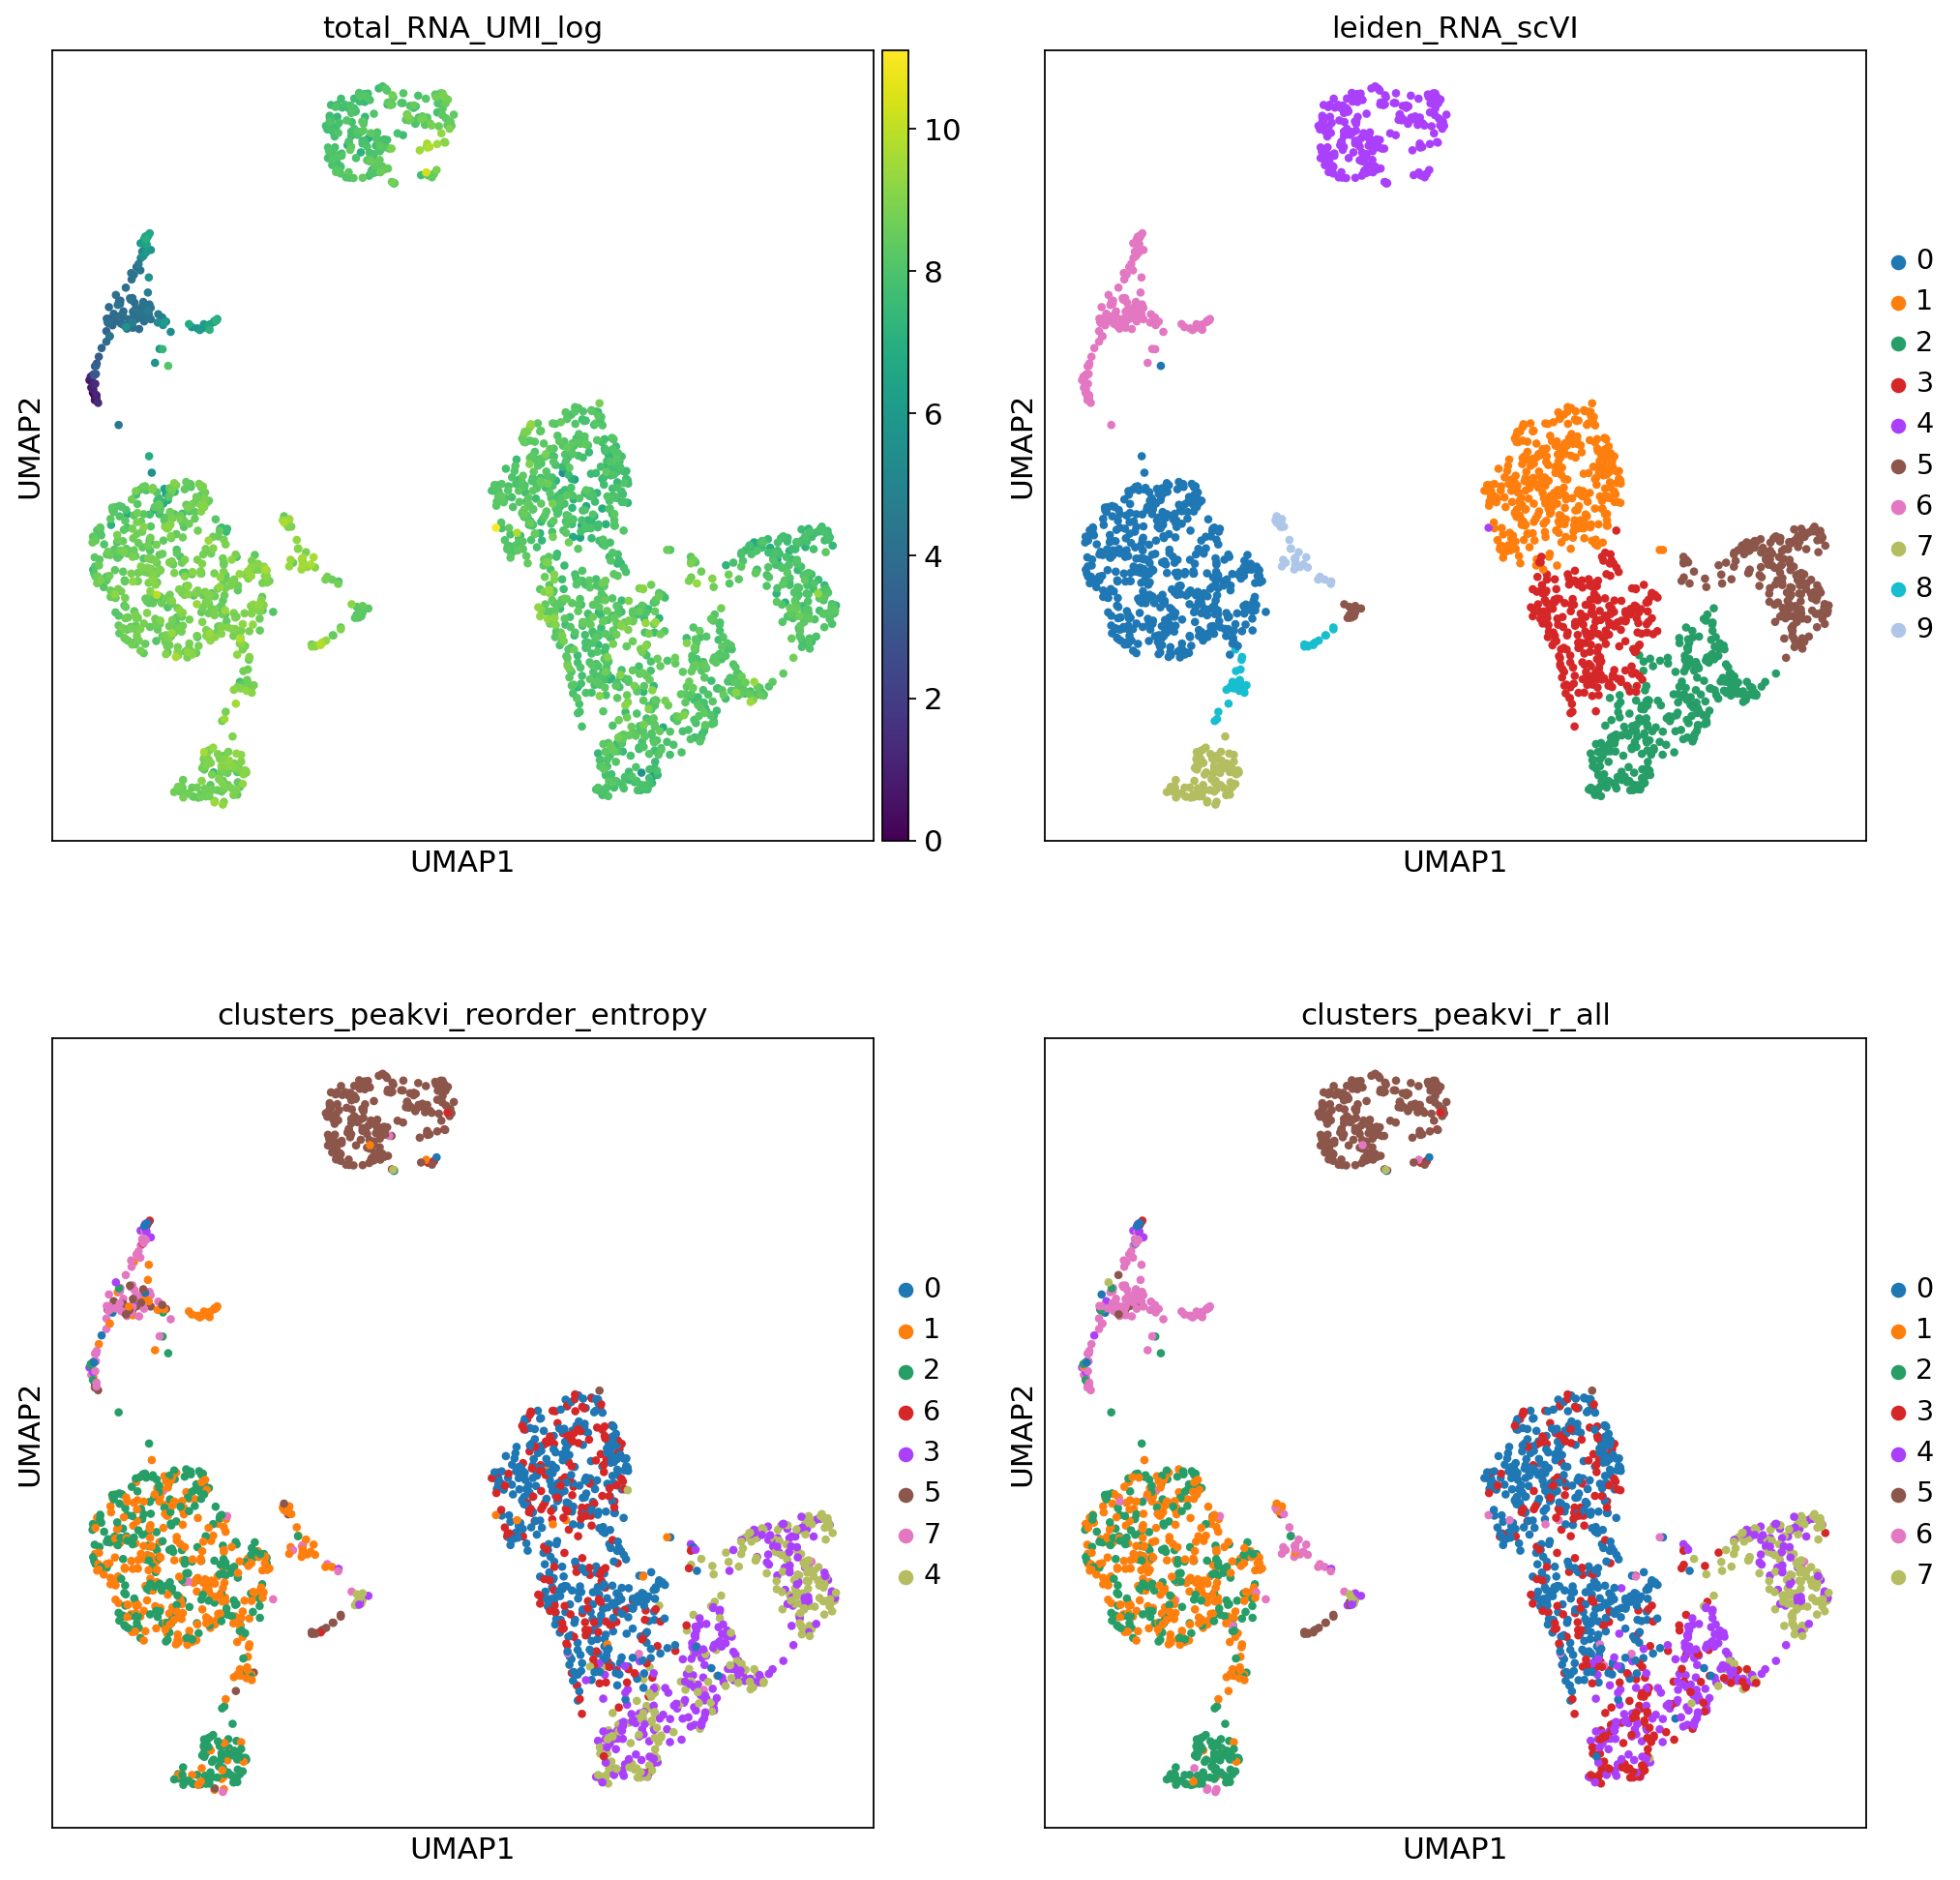

In [123]:
with plt.rc_context({'figure.figsize': (7, 7)}):
    sc.pl.umap(h5_rna, color=['total_RNA_UMI_log', 'leiden_RNA_scVI', 'clusters_peakvi_reorder_entropy', 'clusters_peakvi_r_all'], wspace=0.1, ncols=2, size=60)

### On finer resolution

In [ ]:
relate_labels2 = peak_df.join(entropy_peak_df['clusters_peakvi_entropy']).groupby(['clusters_peakvi_all', 'clusters_peakvi_entropy']).size().unstack(fill_value=0)

relate_labels2 = relate_labels2.to_numpy()

ordered_col, remained_col = order_m(relate_labels2)

relate_labels2[:, ordered_col + remained_col]

# # Now manually map the best matching clusters
entropy_peak.obs['clusters_peakvi_entropy2'] = entropy_peak.obs['clusters_peakvi_entropy'].cat.reorder_categories([str(i) for i in ordered_col+remained_col], ordered=False)



relate_labels2[:, ordered_col + remained_col]

/tmp/ipykernel_3915683/1379188573.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  relate_labels2 = peak_df.join(entropy_peak_df['clusters_peakvi_entropy']).groupby(['clusters_peakvi_all', 'clusters_peakvi_entropy']).size().unstack(fill_value=0)


array([[306,   0,   3,   0,  13,   0,   0,   0,   0,   1,   0,   0,  76],
       [  0, 278,   0,   0,   0,   0,   0,   0,   0,   2,   1,  18,   0],
       [  0,   0, 243,   0,   0,   1,   2,   4,   0,   1,   0,   0,  13],
       [  0,   8,   0, 126,   0,   0,   0,   0,   0,   0,   2, 124,   0],
       [ 10,   0,   0,   0, 178,   0,   0,   1,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   1, 141,   0,   0,   0,   1,  40,   0,   0],
       [  0,   0,  12,   0,   0,   0, 108,  31,   0,   0,   0,   0,   0],
       [  1,   0,   2,   0,  20,   0,   0,  99,   0,   0,   0,   0,   4],
       [  0,   0,   0,  47,   7,   0,   0,   0,  55,   1,   0,   0,   0],
       [  1,   5,   2,   0,   0,  10,   0,   0,  14,  62,   3,   1,   1],
       [  0,   0,   0,   0,   0,   1,   2,   0,   1,   2,  39,   0,   0]])

In [127]:
if 'clusters_peakvi_r_entropy' in h5_rna.obs.columns:
    h5_rna.obs.drop('clusters_peakvi_r_entropy', axis=1, inplace=True)
if 'clusters_peakvi_entropy2' in h5_rna.obs.columns:
    h5_rna.obs.drop('clusters_peakvi_entropy2', axis=1, inplace=True)

if 'clusters_peakvi_all' in h5_rna.obs.columns:
    h5_rna.obs.drop('clusters_peakvi_all', axis=1, inplace=True)
if 'clusters_peakvi_r_all' in h5_rna.obs.columns:
    h5_rna.obs.drop('clusters_peakvi_r_all', axis=1, inplace=True)
    

h5_rna.obs = h5_rna.obs.merge(entropy_peak.obs[['clusters_peakvi_r_entropy', 'clusters_peakvi_entropy2']], left_on='atac_bc', right_index=True, how='left')
# h5_rna.obs.rename(columns={'clusters_peakvi':'clusters_peakvi_entropy'}, inplace=True)
h5_rna.obs = h5_rna.obs.merge(peak.obs[['clusters_peakvi_all', 'clusters_peakvi_r_all']], left_on='atac_bc', right_index=True, how='left')

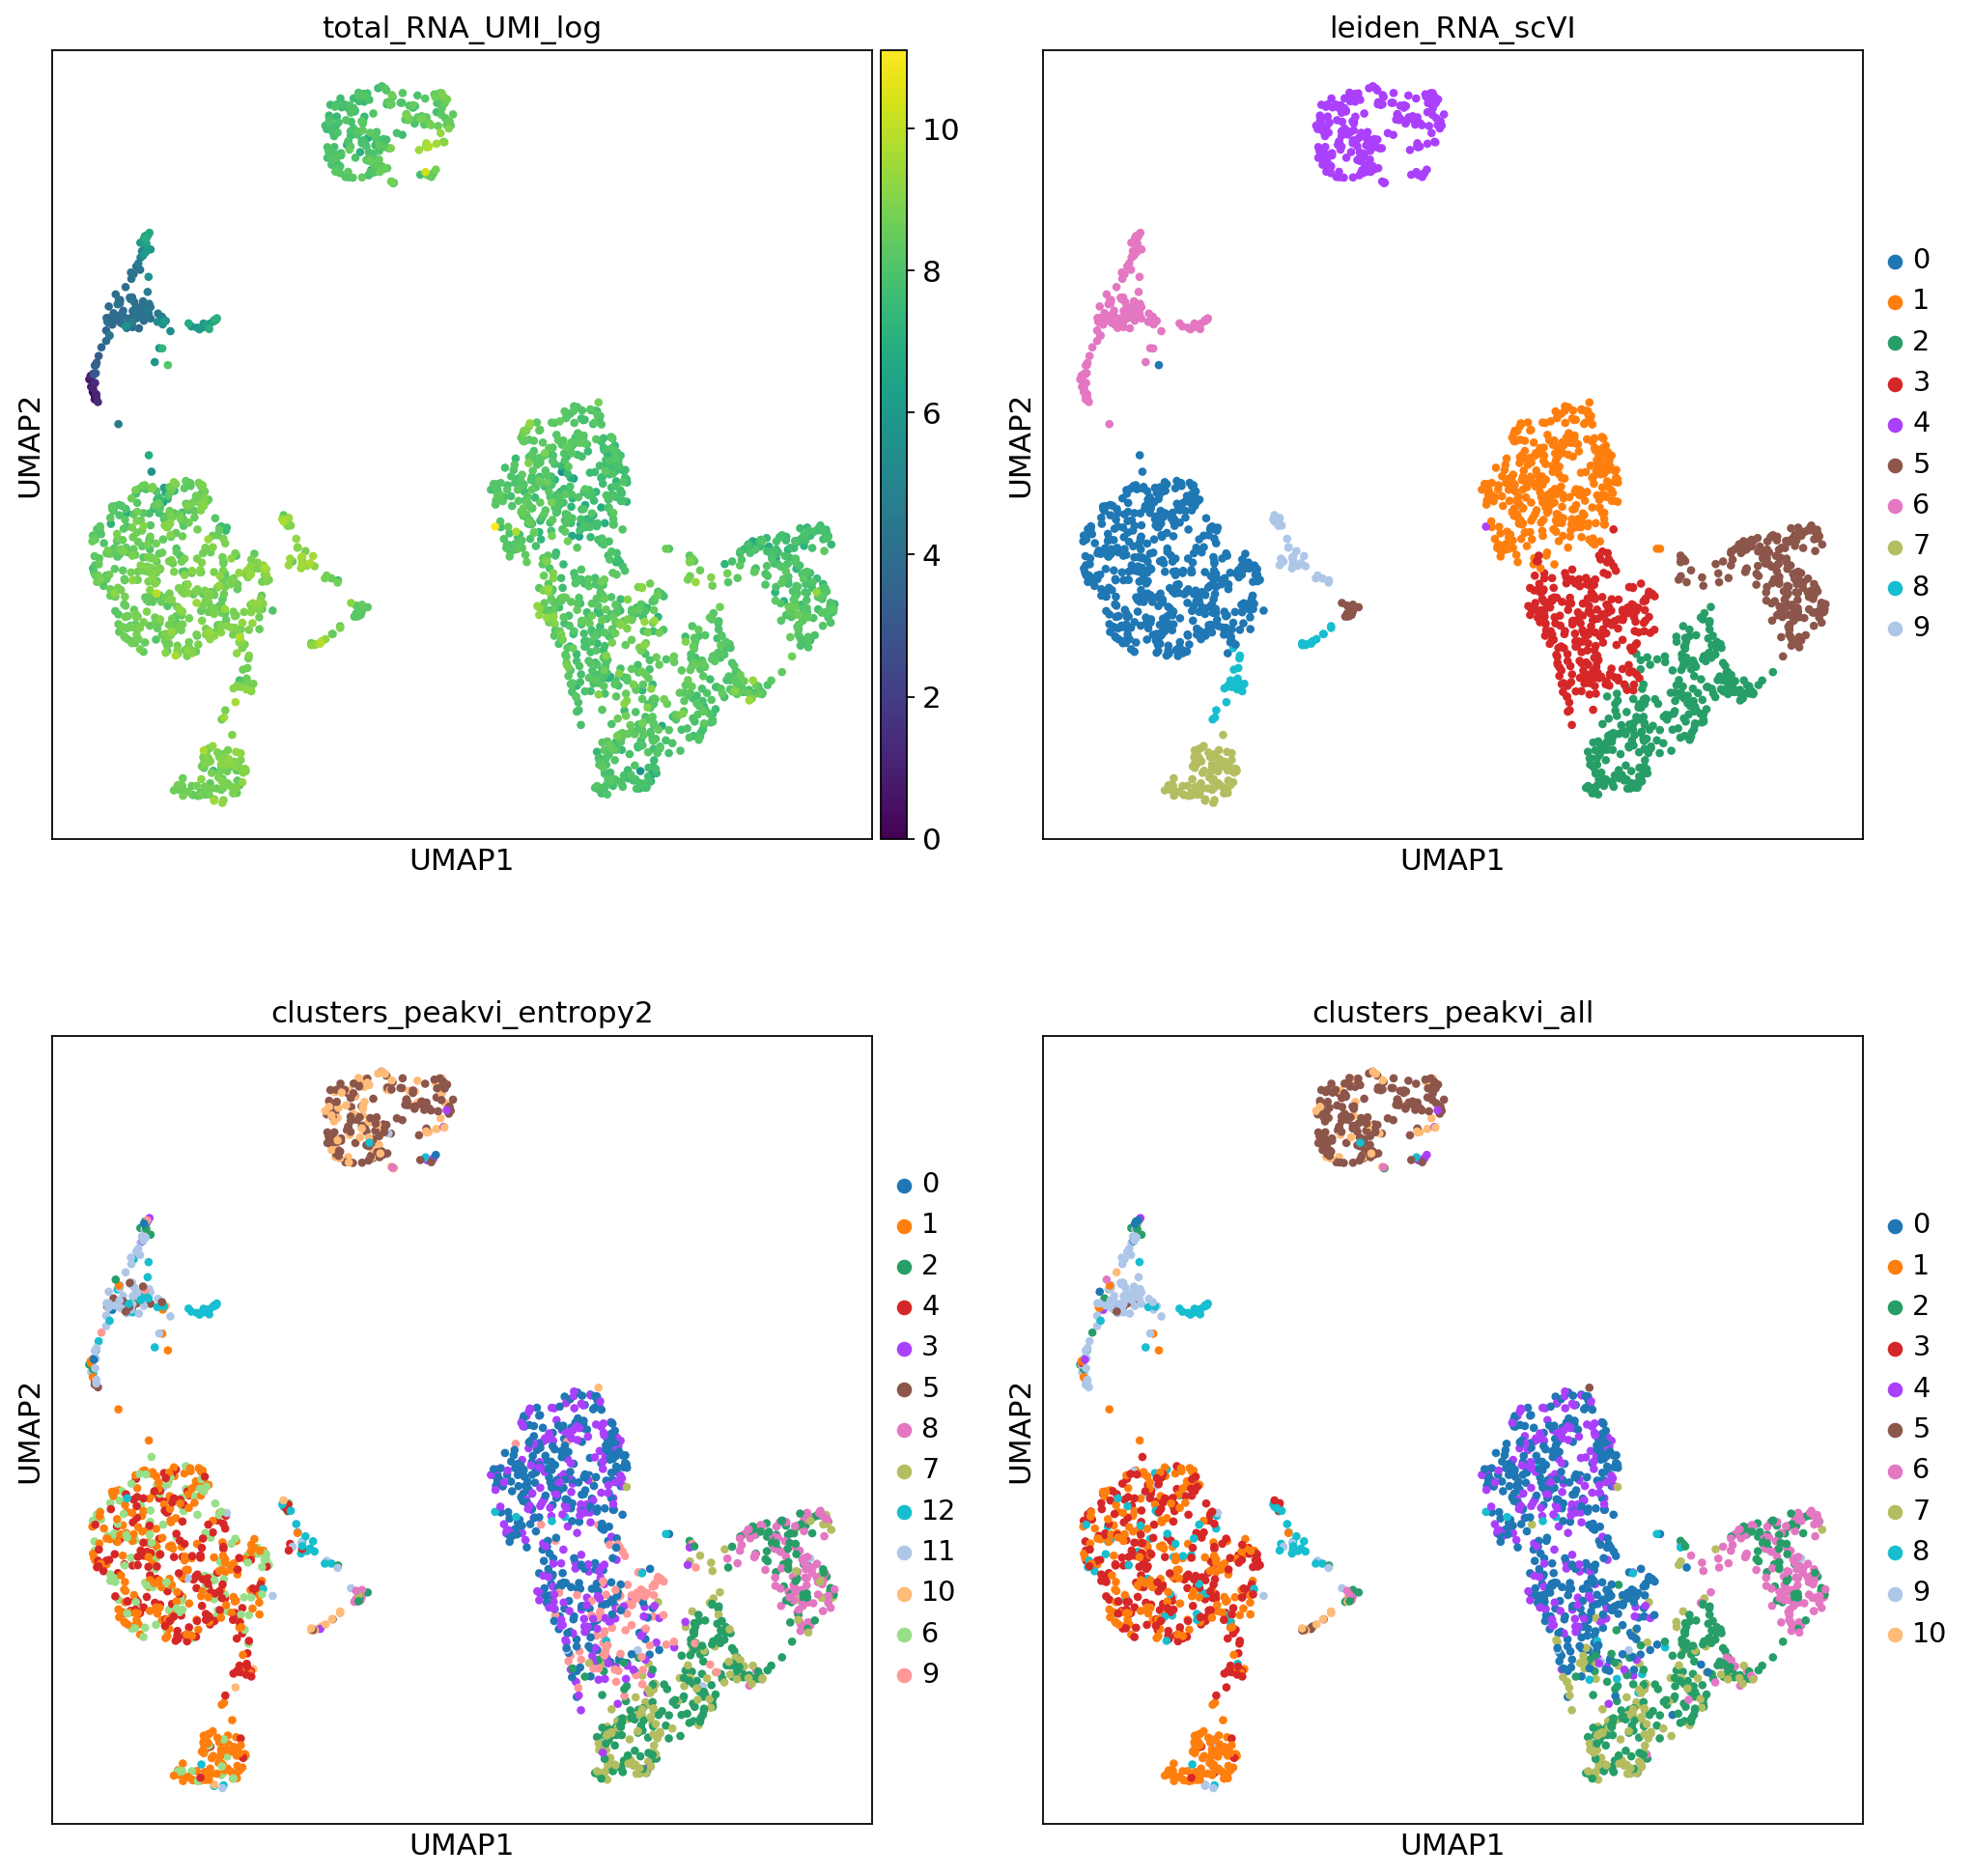

In [128]:
with plt.rc_context({'figure.figsize': (7, 7)}):
    sc.pl.umap(h5_rna, color=['total_RNA_UMI_log', 'leiden_RNA_scVI', 'clusters_peakvi_entropy2', 'clusters_peakvi_all'], wspace=0.1, ncols=2, size=60)

## Umap on ATAC space 

In [133]:
if 'leiden_RNA_scVI' in entropy_peak.obs.columns:
    entropy_peak.obs.drop('leiden_RNA_scVI', axis=1, inplace=True)
if 'leiden_RNA_scVI' in peak.obs.columns:
    peak.obs.drop('leiden_RNA_scVI', axis=1, inplace=True)
    
entropy_peak.obs = entropy_peak.obs.merge(h5_rna.obs[['leiden_RNA_scVI']], left_on='rna_barcodes', right_index=True, how='left')
peak.obs = peak.obs.merge(h5_rna.obs[['leiden_RNA_scVI']], left_on='rna_barcodes', right_index=True, how='left')

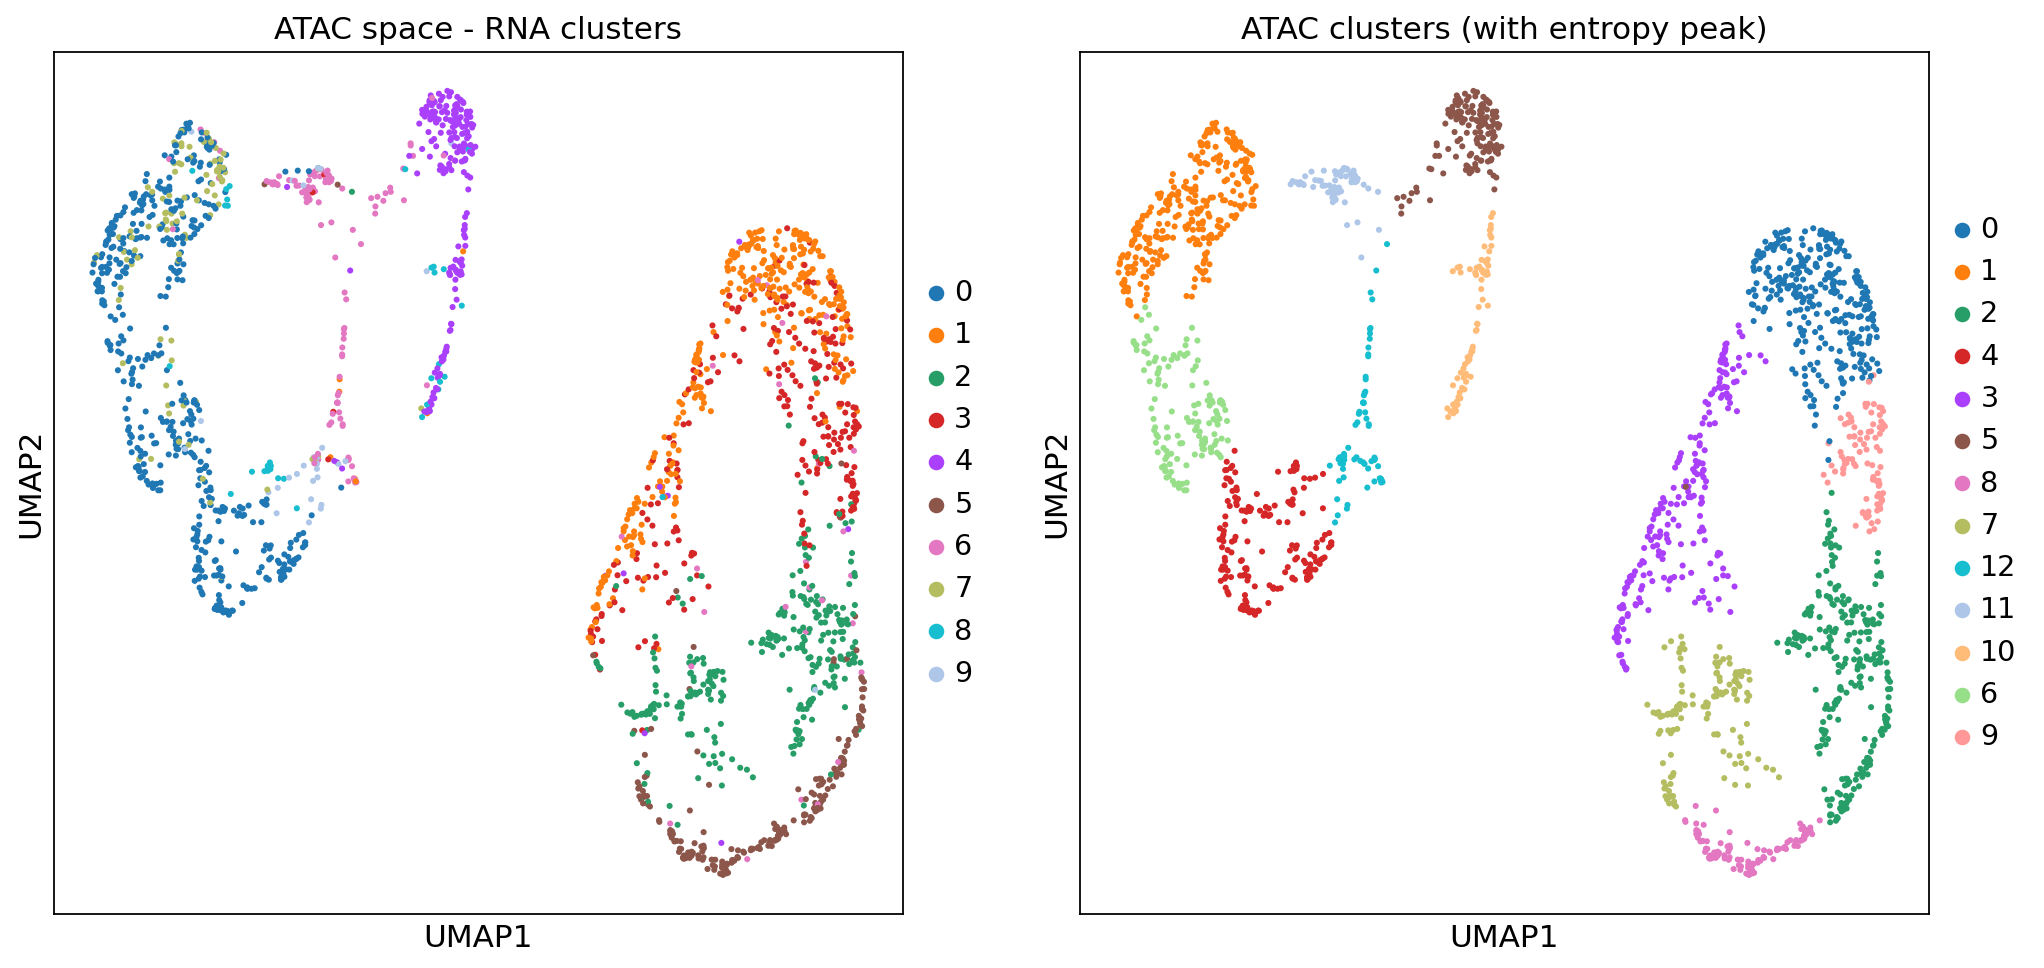

In [138]:
with plt.rc_context({'figure.figsize': (7, 7)}):
    sc.pl.umap(entropy_peak, color=['leiden_RNA_scVI', 'clusters_peakvi_entropy2'], wspace=0.1,title=['ATAC space - RNA clusters', 'ATAC clusters (with entropy peak)'], size=30)

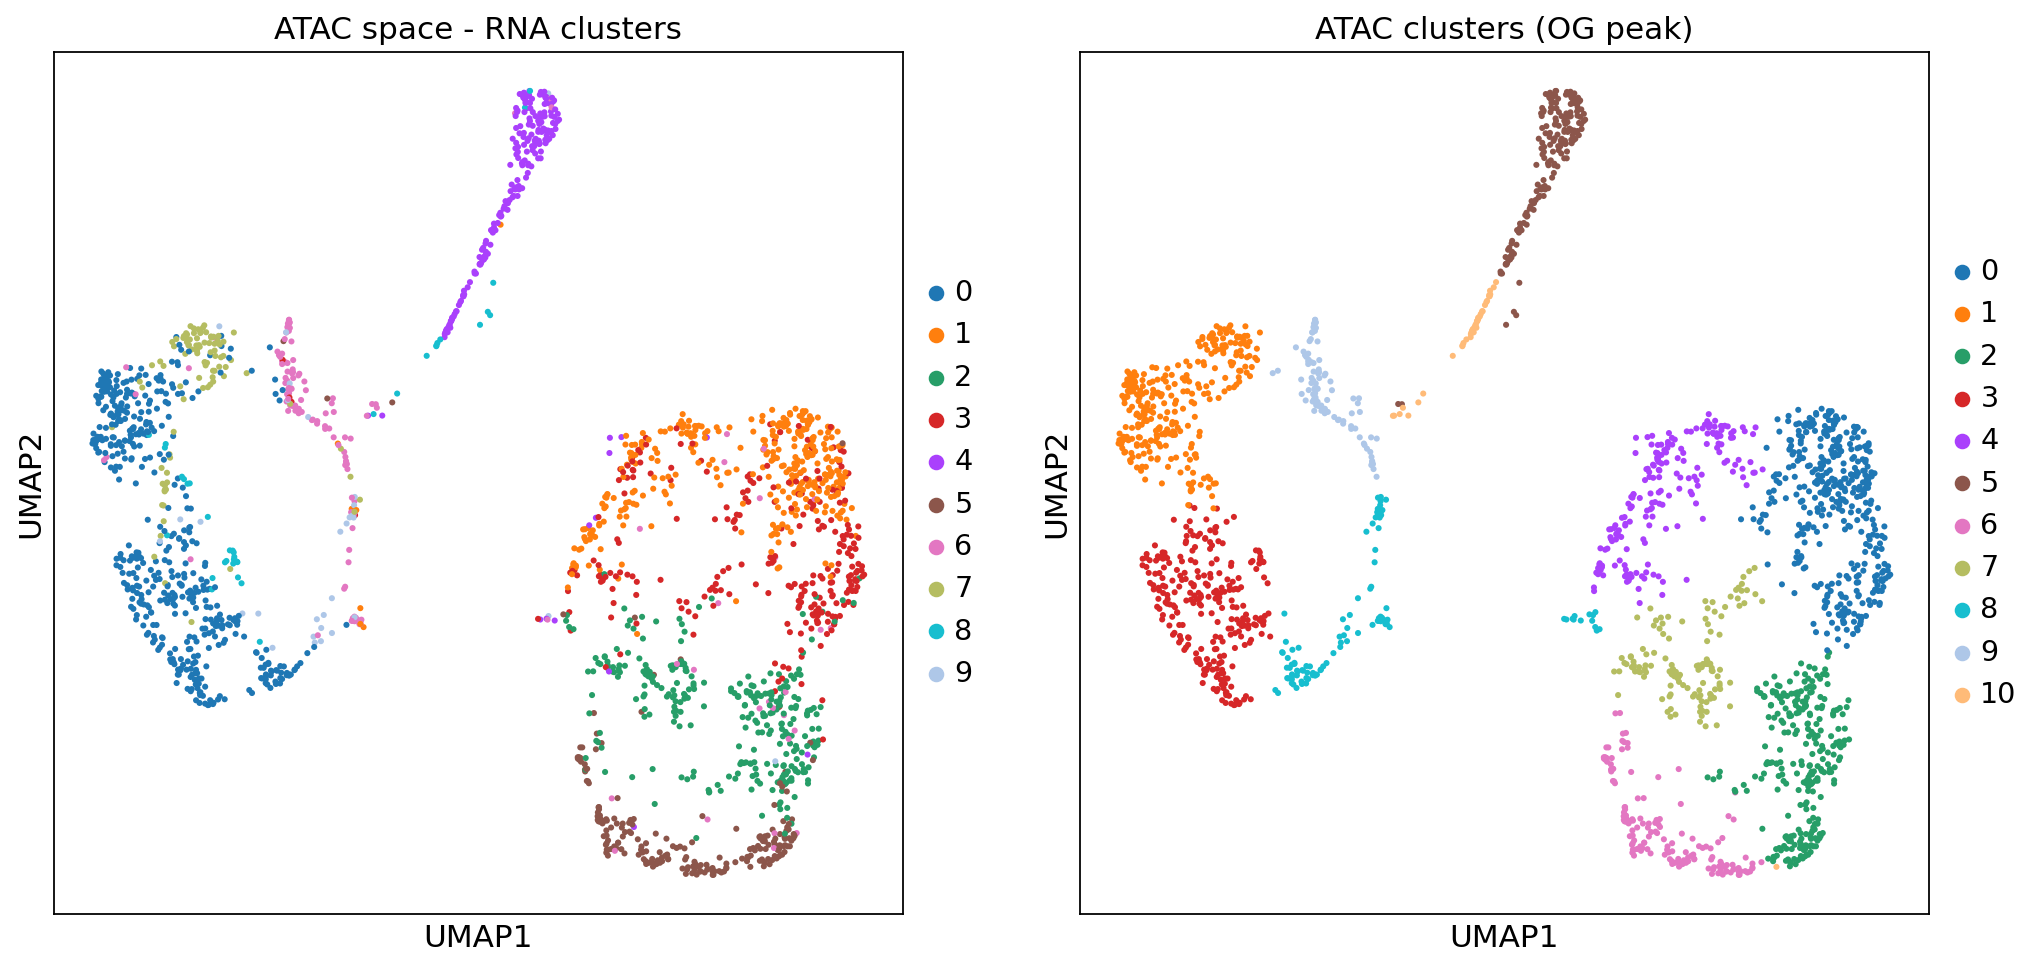

In [136]:
with plt.rc_context({'figure.figsize': (7, 7)}):
    sc.pl.umap(peak, color=['leiden_RNA_scVI', 'clusters_peakvi_all'], wspace=0.1, title=['ATAC space - RNA clusters', 'ATAC clusters (OG peak)'], size=30)

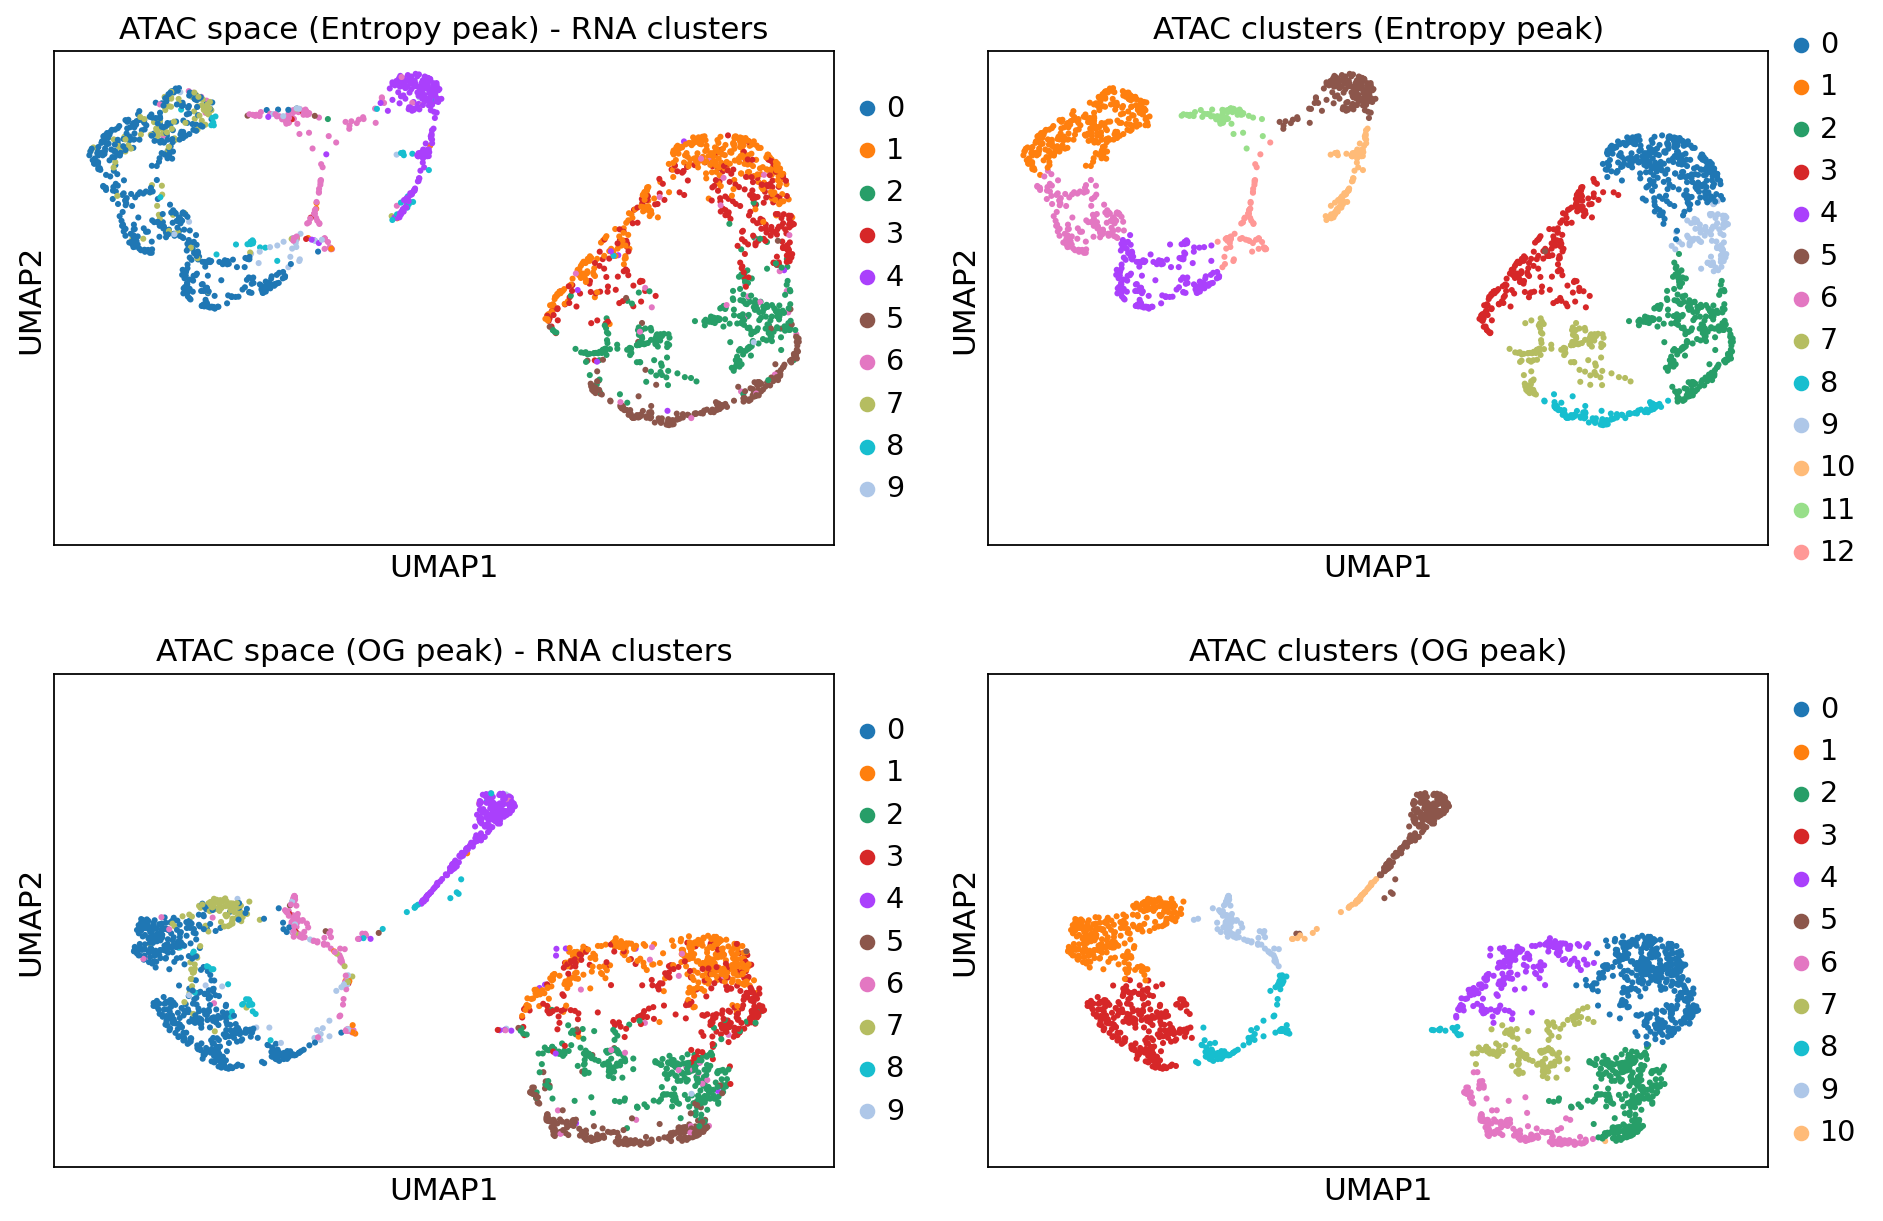

In [137]:
fig, ax = plt.subplots(2, 2, figsize=(12,8), sharex=True, sharey=True)
ax = ax.flatten()
sc.pl.umap(entropy_peak, color=['leiden_RNA_scVI'], title='ATAC space (Entropy peak) - RNA clusters', size=30, ax=ax[0], show=False)
sc.pl.umap(entropy_peak, color=['clusters_peakvi_entropy'], title='ATAC clusters (Entropy peak)', size=30, ax=ax[1], show=False)
sc.pl.umap(peak, color=['leiden_RNA_scVI'], title='ATAC space (OG peak) - RNA clusters', size=30, ax=ax[2], show=False)
sc.pl.umap(peak, color=['clusters_peakvi_all'], title='ATAC clusters (OG peak)', size=30, ax=ax[3], show=False)

fig.tight_layout()